#### Import numpy & keras

In [1]:
%pip install tensorboard keras tensorflow[and-cuda] datasets --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import keras
from datasets import load_dataset, DatasetDict, Image, Dataset
import datetime

I0000 00:00:1779882989.537779 1366117 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779882989.568886 1366117 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779882990.203324 1366117 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
tf.config.optimizer.set_jit(False)
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))


2.21.0
Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1779882991.563311 1366117 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


### Bilder normalisieren

In [4]:
def transform(example):
    image = np.array(example["image"], dtype=np.float32) / 255.0
    return {"image": image, "label": example["label"]}


#### 1. get training data

In [5]:
import matplotlib.pyplot as plt
import PIL
print(PIL.__version__)

ds = load_dataset("jonathan-roberts1/NWPU-RESISC45")
print(ds.shape)

train_data = ds["train"]
split_1 = train_data.train_test_split(
    test_size=0.15,
    seed=42,          # sorgt dafür, dass Validation immer gleich bleibt
    shuffle=True
)

validation_dataset = split_1["test"]

12.1.1
{'train': (31500, 2)}


In [6]:
remaining_dataset = split_1["train"]
split_2 = remaining_dataset.train_test_split(
    test_size=0.25,
    shuffle=True
)

train_ds = split_2["train"]

In [7]:
# -----------------------------                                              │
# AUGMENTER                                                                  │
# Augmentation folgt On-the-fly im Trainigsprozess über 
# AUTOTUNE (entscheidet selbst, wie viele CPU Kerne es nutzt)
# -----------------------------   

augmenter = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.5),
    keras.layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    keras.layers.RandomContrast(0.15),
])

print("Trainingsdaten:", len(train_ds))

Trainingsdaten: 20081


W0000 00:00:1779882993.694129 1366117 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779882993.788476 1366117 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1779882993.789222 1366117 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94894 MB memory:  -> device: 0, name: NVIDIA RTX PRO 6000 Blackwell Server Edition, pci bus id: 0000:11:00.0, compute capability: 12.0a


In [8]:
from datasets import DatasetDict

test_ds = split_2["test"]

final_dataset = DatasetDict({
    "train": train_ds,
    "validation": validation_dataset,
    "test": test_ds
})

# final_dataset mit transform bleibt für Predictions in späteren Zellen erhalten
final_dataset = final_dataset.with_transform(transform)

print(final_dataset)

# HuggingFace liest per to_tf_dataset() jeden Batch einzeln aus Arrow-Dateien
# (~200 ms I/O-Overhead pro Batch). Deshalb: alle Splits einmalig als uint8-Array
# in den RAM laden. tf.data.from_tensor_slices() greift dann direkt auf den
# Arbeitsspeicher zu und braucht nur noch ~5 ms pro Batch.
print("Lade Daten einmalig in RAM...")

def to_numpy(hf_split, batch_size=2000):
    imgs, lbls = [], []
    for batch in hf_split.iter(batch_size=batch_size):
        imgs.append(np.array(batch["image"], dtype=np.uint8))
        lbls.extend(batch["label"])
    return np.concatenate(imgs), np.array(lbls, dtype=np.int32)

x_train, y_train = to_numpy(train_ds)
x_val,   y_val   = to_numpy(validation_dataset)
x_test,  y_test  = to_numpy(test_ds)
print(f"train={x_train.shape}, val={x_val.shape}, test={x_test.shape}")

# Normalisierung als schnelle TF-Op in der Pipeline (uint8 → float32 / 255)
@tf.function
def preprocess(img, lbl):
    return tf.cast(img, tf.float32) / 255.0, lbl

tf_train = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(len(x_train), reshuffle_each_iteration=True)
    .batch(128)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
tf_val = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(128)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
tf_test = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(128)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# Klassen
class_names = final_dataset["train"].features["label"].names
print(class_names)

# Bildform prüfen
img_shape = x_train[0].shape
print(img_shape)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 20081
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 4725
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 6694
    })
})
Lade Daten einmalig in RAM...
train=(20081, 256, 256, 3), val=(4725, 256, 256, 3), test=(6694, 256, 256, 3)
['airplane', 'airport', 'baseball diamond', 'basketball court', 'beach', 'bridge', 'chaparral', 'church', 'circular farmland', 'cloud', 'commercial area', 'dense residential', 'desert', 'forest', 'freeway', 'golf course', 'ground track field', 'harbor', 'industrial area', 'intersection', 'island', 'lake', 'meadow', 'medium residential', 'mobile home park', 'mountain', 'overpass', 'palace', 'parking lot', 'railway', 'railway station', 'rectangular farmland', 'river', 'roundabout', 'runway', 'sea ice', 'ship', 'snowberg', 'sparse residential', 'stadium', 'storage tank', 'tennis court', 'terrace', '

#### 2. define architecture

In [61]:
inception = keras.applications.InceptionV3(include_top = False,
                                      weights = "imagenet",
                                      input_shape = img_shape,
                                      pooling= "avg")
model_name = "InceptionV3_avgPOOL_batch"

load model

In [62]:
from keras import Sequential, layers

for layer in inception.layers:
    layer.trainable = False

model = Sequential()
model.add(inception)
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.4))
model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dense(45, activation="softmax"))
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_755         │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 45)             │        23,085 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,883,149 (87.29 MB)

 Trainable params: 1,076,269 (4.11 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

#### 3. set training parameter and fit model

# non-specific callbacks

In [63]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

In [64]:
# Augmentierung auf GPU: nur aktiv wenn training=True
model = tf.keras.Sequential([augmenter, model])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

savepath = "./models/" + model_name + ".keras"
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=savepath,
    save_freq="epoch",
    save_best_only=False,
    verbose=1
)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=200,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
)

model.save(savepath)

Epoch 1/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.6271 - loss: 1.3693 - val_accuracy: 0.7399 - val_loss: 0.9110 - learning_rate: 0.0010
Epoch 2/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7310 - loss: 0.9385 - val_accuracy: 0.7823 - val_loss: 0.7184 - learning_rate: 0.0010
Epoch 3/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7570 - loss: 0.8385 - val_accuracy: 0.7971 - val_loss: 0.6905 - learning_rate: 0.0010
Epoch 4/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.7670 - loss: 0.7821 - val_accuracy: 0.8049 - val_loss: 0.6520 - learning_rate: 0.0010
Epoch 5/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.7832 - loss: 0.7211 - val_accuracy: 0.8082 - val_loss: 0.6420 - learning_rate: 0.0010
Epoch 6/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7883 - loss: 0.7042 - val_accuracy: 0.8073 - val_loss: 0.6349 - learning_rate: 0.0010
Epoch 7/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7

In [69]:
model = keras.models.load_model("./models/" + model_name + ".keras")

for layer in inception.layers[-110:]:           
    layer.trainable = True

model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=200,
    callbacks=[tensorboard_callback, early_stopping, reduce_lr],
    initial_epoch=43,
)

model.save(savepath)

Epoch 44/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.8734 - loss: 0.3917 - val_accuracy: 0.8578 - val_loss: 0.4623 - learning_rate: 1.0000e-05
Epoch 45/200
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8767 - loss: 0.3893
Epoch 45: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.8727 - loss: 0.3913 - val_accuracy: 0.8585 - val_loss: 0.4618 - learning_rate: 1.0000e-05
Epoch 46/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.8750 - loss: 0.3856 - val_accuracy: 0.8585 - val_loss: 0.4617 - learning_rate: 3.0000e-06
Epoch 47/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8753 - loss: 0.3798
Epoch 47: ReduceLROnPlateau reducing learning rate to 1e-06.
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.8739 - loss: 0.3857 - val_accuracy: 0.8588 - val_loss: 0.4618 - learning_rate: 3.0000e-06
Epoch 48/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
                       precision    recall  f1-score   support

             airplane      0.929     0.878     0.903       148
              airport      0.891     0.898     0.895       137
     baseball diamond      0.925     0.925     0.925       147
     basketball court      0.853     0.875     0.864       152
                beach      0.928     0.955     0.941       134
               bridge      0.920     0.958     0.939       168
            chaparral      0.987     0.993     0.990       149
               church      0.764     0.764     0.764       144
    circular farmland      0.974     1.000     0.987       152
                cloud      1.000     0.941     0.970       136
      commercial area      0.849     0.854     0.851       151
    dense residential      0.926     0.868     0.896       159
               desert      0.955     0.955     0.955       157
               forest      0.925     0.951     0.938       142
              

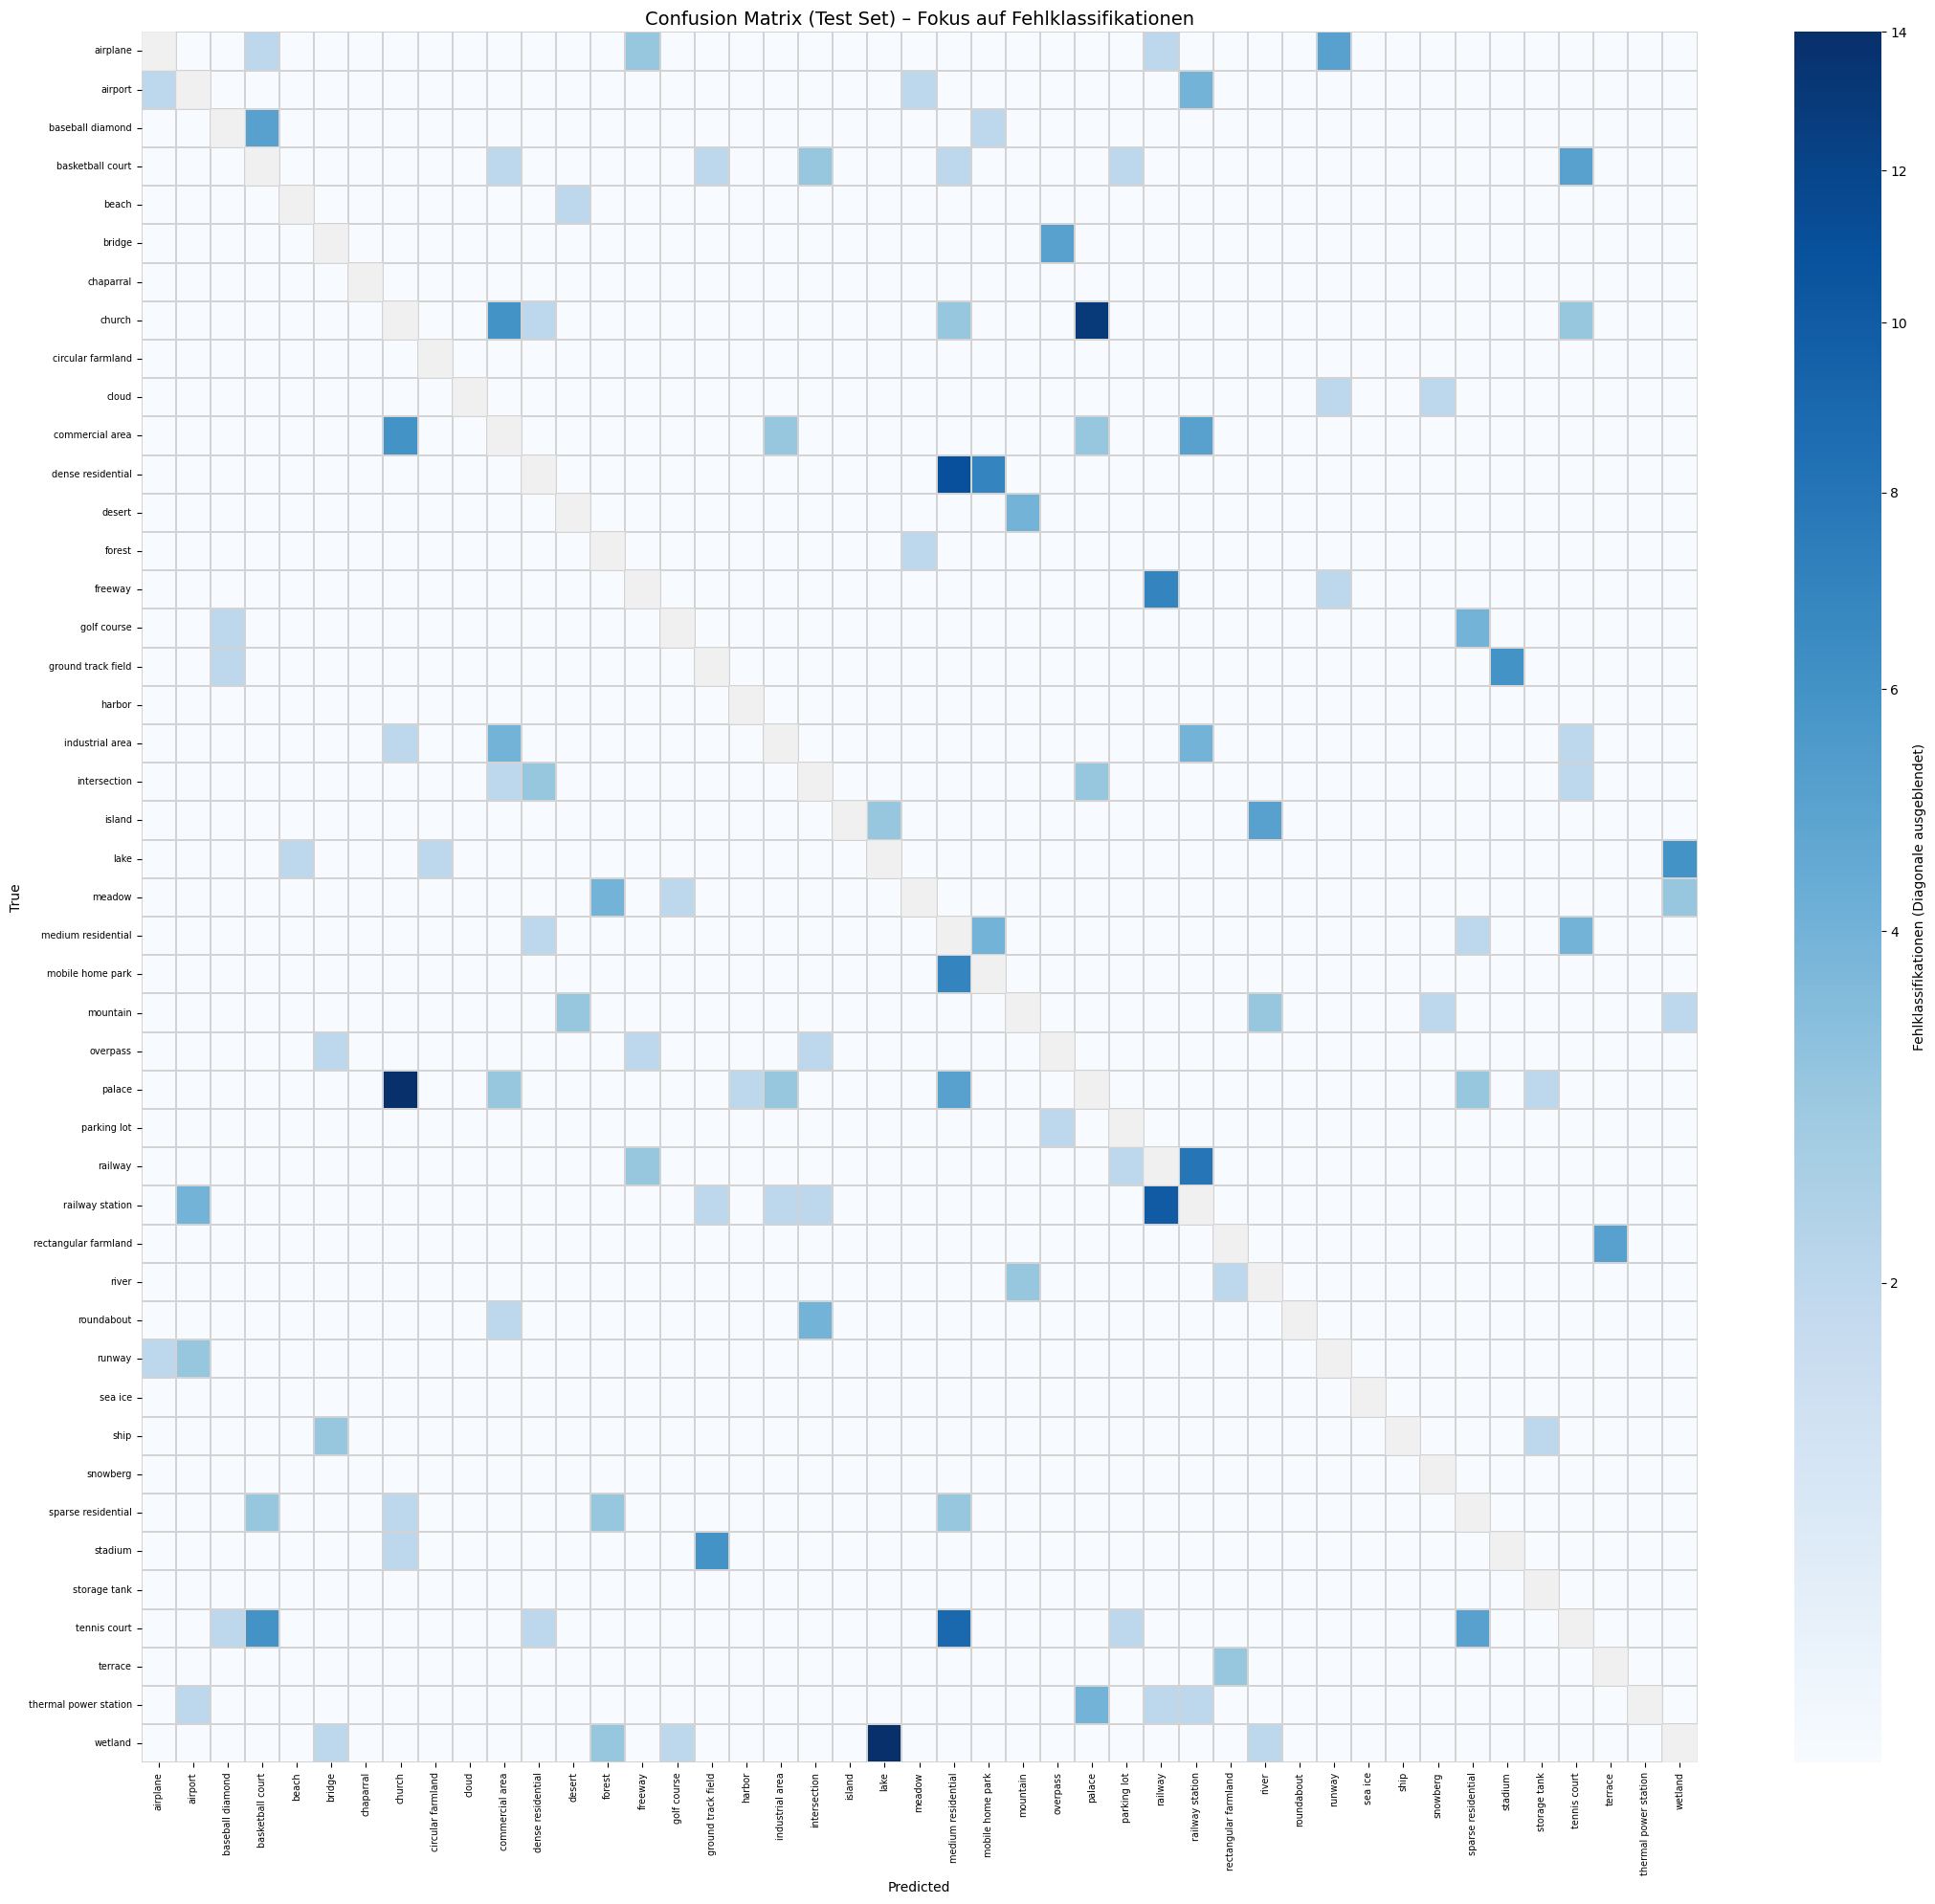

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib.colors import PowerNorm
import numpy as np

 # predictions on test set
y_pred_probs = model.predict(tf_test)
y_pred = np.argmax(y_pred_probs, axis=1)

 # accuracy per class
report = classification_report(y_test, y_pred, target_names=class_names, digits=3)
print(report)

 # heatmap
cm = confusion_matrix(y_test, y_pred)
cm_errors = cm.astype(float).copy()
np.fill_diagonal(cm_errors, np.nan)

plt.figure(figsize=(22, 20))
ax = sns.heatmap(
     cm_errors,
     annot=False,
     cmap="Blues",
     norm=PowerNorm(gamma=0.5, vmin=1, vmax=np.nanmax(cm_errors)),
     xticklabels=class_names,
     yticklabels=class_names,
     linewidths=0.3,
     linecolor="lightgrey",
     cbar_kws={"label": "Fehlklassifikationen (Diagonale ausgeblendet)"},
 )
# make diagonal less obvious
for i in range(len(class_names)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, facecolor="#f0f0f0", edgecolor="lightgrey", lw=0.3))

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()


In [13]:
#%load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir logs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/opt/conda/bin/tensorboard", line 3, in <module>
    from tensorboard.main import run_main
  File "/opt/conda/lib/python3.13/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/opt/conda/lib/python3.13/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

#### 4. predict output 

Index: 6523
Predicted: mobile home park
True: stadium


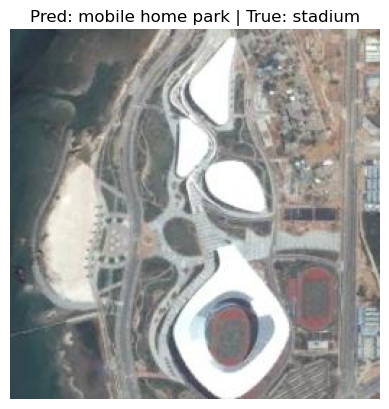

In [14]:
import random

# Zufälligen Index wählen
idx = random.randint(0, len(final_dataset["test"]) - 1)

# Sample holen
sample = final_dataset["test"][idx]

# Bild und echtes Label
img = sample["image"]
true_idx = sample["label"]

# Batch-Dimension hinzufügen
input_img = np.expand_dims(img, axis=0)

# Prediction
prediction = model.predict(input_img, verbose=0)

# Vorhersageklasse
predicted_idx = np.argmax(prediction)

# Ausgabe
print("Index:", idx)
print("Predicted:", class_names[predicted_idx])
print("True:", class_names[true_idx])

# Bild anzeigen
plt.imshow(img)
plt.title(f"Pred: {class_names[predicted_idx]} | True: {class_names[true_idx]}")
plt.axis("off")
plt.show()